# <a id='toc1_'></a>[triple N](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [triple N](#toc1_)    
  - [📆 data as of](#toc1_1_)    
  - [dataset](#toc1_2_)    
  - [🕹️ interactive](#toc1_3_)    
  - [📉 plots](#toc1_4_)    
    - [HormonrezeptorStatus_Oestrogen](#toc1_4_1_)    
    - [Anzahl_Tage_Diagnose_SYST](#toc1_4_2_)    
      - [groups](#toc1_4_2_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [ ]:
import os
from pathlib import Path
import pandas as pd
import duckdb as ddb
from pandas_plots import tbl, pls, hlp
from connection_helper import sql

hlp.show_package_version()
os.environ['THEME']="light"
os.environ['DEBUG']="0"
os.environ['RENDERER']=""

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

file_db_clin = dir_db/'2025-11-11_data_clin.duckdb'

if not file_db_clin.exists():
    raise FileNotFoundError(f"File not found: {file_db_clin}")

🐍 3.12.8 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.4.2 | 📦 pandas-plots: 0.23.1 | 📦 connection-helper: 0.13.2


In [2]:
con = ddb.connect(file_db_clin.as_posix(), read_only=True)
_=con.execute("PRAGMA disable_progress_bar;")

## <a id='toc1_1_'></a>[📆 data as of](#toc0_)

In [3]:
sql.print_meta(file_db_clin)

database file:           2025-11-11_data_clin.duckdb
data tag:                v2.3
last kkr data import:    2025-09-30
sql table created:       2025-11-11 11:52:01
doi:                     10.18444/5.03.01.0005.0021.0002
document created:        2025-11-28 13:46:07


## <a id='toc1_2_'></a>[dataset](#toc0_)

- **Tabellen**
  - `Tumor` - gefiltert
  - `OP` - nur erste pro Tumor
  - `SYST` - nur erste pro Tumor

- **nicht-standard Variablen**
  - `has_ops_5401` - true wenn dem Tumor >= 1 OPS `5-401.11` zugeordnet ist
  - `has_pembro` - true wenn dem Tumor >= 1 Substanz _oder_ Protokoll zugeordnet ist:
    - Code = `L01FF02`
    - _oder_ Bezeichnung = `Pembro|Keytruda` (regex)

- **Filter**
  - `z_icd10`: C50, D05
  - `z_sex`: w
  - `z_dy`: 2020 - 2023

- **Metriken**
  - es werden **Tumore** gezählt, jede 1:n Information (z.B. Behandlungen) gibt es nur einmal pro Tumor

In [4]:
FILTER_DY = "z_dy between 2020 and 2023"
FILTER_ICD = "z_icd10_3d in ('C50','D05')"
FILTER_CHEMO = "Therapieart = 'CH'"
FILTER_3N = "is_3n"
FILTER_RISK = "has_risk"
FILTER_PEMBRO = "has_pembro"

In [5]:
db_1_all = con.sql("""--sql
    select
            --tum
            tum.z_tum_id, tum.z_pat_id,
            z_kkr_label,
            z_age,
            z_dy,
            z_sex,
            z_icd10_3d, z_icd10,
            Grading,
            Her2neuStatus, Praetherapeutischer_Menopausenstatus, HormonrezeptorStatus_Oestrogen, HormonrezeptorStatus_Progesteron,
            z_t_c_0, z_n_c_0, z_m_c_0,
            z_t_p_0, z_n_p_0, z_m_p_0, z_m_pc_1, y_Symbol_p,

            -- op
            z_period_diag_op_day,

            -- syst
            Therapieart,
            z_period_diag_syst_day,
            SYST_TypSubstanzATC_Code,

            (Her2neuStatus = 'N' and HormonrezeptorStatus_Progesteron = 'N' and HormonrezeptorStatus_Oestrogen = 'N') as is_3n,

            (
                (z_n_c_1 in ('0','1','2') and z_t_c_1 in ('2', '3', '4')) OR
                (z_n_c_0 in ('1c') and z_t_c_1 in ('1', '2'))
            ) as has_risk,

            (
                regexp_matches(sub.Bezeichnung, 'Pembro|Keytruda|L01FF02', 'i') or
                regexp_matches(SYST_TypSubstanzATC_Code, 'Pembro|Keytruda|L01FF02', 'i') or
                regexp_matches(z_substance_prediction_name, 'Pembro|Keytruda|L01FF02', 'i') or
                regexp_matches(prot.Bezeichnung, 'Pembro|Keytruda|L01FF02', 'i')
            ) as has_pembro,

            -- ypT0/ypTis; ypN0

    from Tumor tum
    left join SYST sy on tum.z_tum_id = sy.z_tum_id
    left join OP op on tum.z_tum_id = op.z_tum_id
    left join Substanz sub on sy.SYSTId = sub.SYSTId
    left join Protokoll prot on sy.SYSTId = prot.SYSTId
    """)

_=con.register("db_1_all_table", db_1_all)

tbl.descr_db(db_1_all, 'db_1_all')

<!-- START_TOKEN -->

🗄️ db_1_all	5_038_341, 28
	("z_tum_id, z_pat_id, z_kkr_label, z_age, z_dy, z_sex, z_icd10_3d, z_icd10, Grading, Her2neuStatus, Praetherapeutischer_Menopausenstatus, HormonrezeptorStatus_Oestrogen, HormonrezeptorStatus_Progesteron, z_t_c_0, z_n_c_0, z_m_c_0, z_t_p_0, z_n_p_0, z_m_p_0, z_m_pc_1, y_Symbol_p, z_period_diag_op_day, Therapieart, z_period_diag_syst_day, SYST_TypSubstanzATC_Code, is_3n, has_risk, has_pembro")


<!-- END_TOKEN -->

┌──────────────────────┬──────────────────────┬─────────────┬────────┬───┬─────────┬──────────┬────────────┐
│       z_tum_id       │       z_pat_id       │ z_kkr_label │ z_age  │ … │  is_3n  │ has_risk │ has_pembro │
│       varchar        │       varchar        │   varchar   │ double │   │ boolean │ boolean  │  boolean   │
├──────────────────────┼──────────────────────┼─────────────┼────────┼───┼─────────┼──────────┼────────────┤
│ 6a004022-38bd-432e…  │ 0744be10-623c-46bf…  │ 11-BE       │  72.08 │ … │ NULL    │ false    │ NULL       │
│ efdb2aa0-295a-4047…  │ 2a17e432-8bca-478b…  │ 09-BY       │  62.33 │ … │ NULL    │ true     │ NULL       │
│ cdb78386-bc38-437f…  │ 0b80e928-3e7d-4226…  │ 09-BY       │  80.17 │ … │ NULL    │ NULL     │ NULL       │
├──────────────────────┴──────────────────────┴─────────────┴────────┴───┴─────────┴──────────┴────────────┤
│ 3 rows                                                                              28 columns (7 shown) │
└──────────────────

In [6]:
FILTERS = [
    (FILTER_DY, ""),
    (FILTER_ICD, ""),
    (FILTER_3N, "triple-N"),
    (FILTER_CHEMO,""),
    (FILTER_RISK, "hochrisiko"),
    (FILTER_PEMBRO, "Pembrolizumab|Keytruda"),
]
hlp.get_duckdb_filter_n(
    con=con,
    query="from db_1_all_table",
    filters=FILTERS,
    distinct_metric="z_tum_id",
)

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 3_241_401                                  (100.0%) ██████████████████████████████
└ [z_dy between 2020 and 2023]:  n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [z_icd10_3d in ('C50','D05')]:   n = 346_612  (10.7%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░███
└ [triple-N]:                       n = 23_688   (0.7%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [Therapieart = 'CH']:             n = 12_914   (0.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [hochrisiko]:                      n = 6_152   (0.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [Pembrolizumab|Keytruda]:            n = 172   (0.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

In [7]:
FILTER = f"""--sql
    {FILTER_DY}
    and {FILTER_ICD}
    and ({FILTER_CHEMO}
    and {FILTER_3N}
    and {FILTER_RISK})
    -- and {FILTER_PEMBRO}
"""

In [8]:
db_2_tum = con.sql(f"""--sql
    with t1 as (
        select
                -- these fields are constant for each tumor
                z_tum_id,
                any_value(z_pat_id) as z_pat_id,
                any_value(z_kkr_label) as z_kkr_label,
                any_value(z_dy) as z_dy,
                any_value(z_age) as z_age,
                any_value(z_icd10_3d) as z_icd10_3d,
                any_value(z_t_c_0) as z_t_c_0,
                any_value(z_n_c_0) as z_n_c_0,
                any_value(z_m_c_0) as z_m_c_0,
                
                -- mark tumor if any constellation was true
                max(has_risk) as has_risk,
                max(has_pembro) as has_pembro,

                -- condition for delta between first occurence: defined filter must apply
                -- min(z_period_diag_syst_day) - min(z_period_diag_op_day) filter(has_prostatektomie and has_adt_in) as adt_prostatektomie_day,
                -- min(z_period_diag_syst_day) - min(z_period_diag_bestr_day) filter(has_perkutan and has_adt_in) as adt_perkutan_day,
        from db_1_all
        where {FILTER}
        group by z_tum_id
    )
    select * from t1
""")
tbl.descr_db(db_2_tum, "grouped to tum")

<!-- START_TOKEN -->

🗄️ grouped to tum	6_152, 11
	("z_tum_id, z_pat_id, z_kkr_label, z_dy, z_age, z_icd10_3d, z_t_c_0, z_n_c_0, z_m_c_0, has_risk, has_pembro")


<!-- END_TOKEN -->

┌──────────────────────┬──────────────────────┬─────────────┬───────┬───┬─────────┬─────────┬──────────┬────────────┐
│       z_tum_id       │       z_pat_id       │ z_kkr_label │ z_dy  │ … │ z_n_c_0 │ z_m_c_0 │ has_risk │ has_pembro │
│       varchar        │       varchar        │   varchar   │ int16 │   │ varchar │ varchar │ boolean  │  boolean   │
├──────────────────────┼──────────────────────┼─────────────┼───────┼───┼─────────┼─────────┼──────────┼────────────┤
│ c3559fca-6356-4057…  │ fcfb1bc7-178b-49b9…  │ 14-SN       │  2021 │ … │ 0       │ 0       │ true     │ NULL       │
│ cfb4c324-f4a6-4ee6…  │ 8ab31663-85fb-466a…  │ 12-BB       │  2021 │ … │ 0       │ 0       │ true     │ NULL       │
│ f2c6624b-4176-43eb…  │ 1d264e01-de92-43d3…  │ 14-SN       │  2020 │ … │ 0       │ 0       │ true     │ NULL       │
├──────────────────────┴──────────────────────┴─────────────┴───────┴───┴─────────┴─────────┴──────────┴────────────┤
│ 3 rows                                                

In [9]:
if os.environ.get("DEBUG") == "1":
    db_2_tum.filter("has_pembro").show()
    hlp.get_tum_details(con=con, z_tum_id="d2af3421-abc6-4434-82eb-e2b61f4ec643")

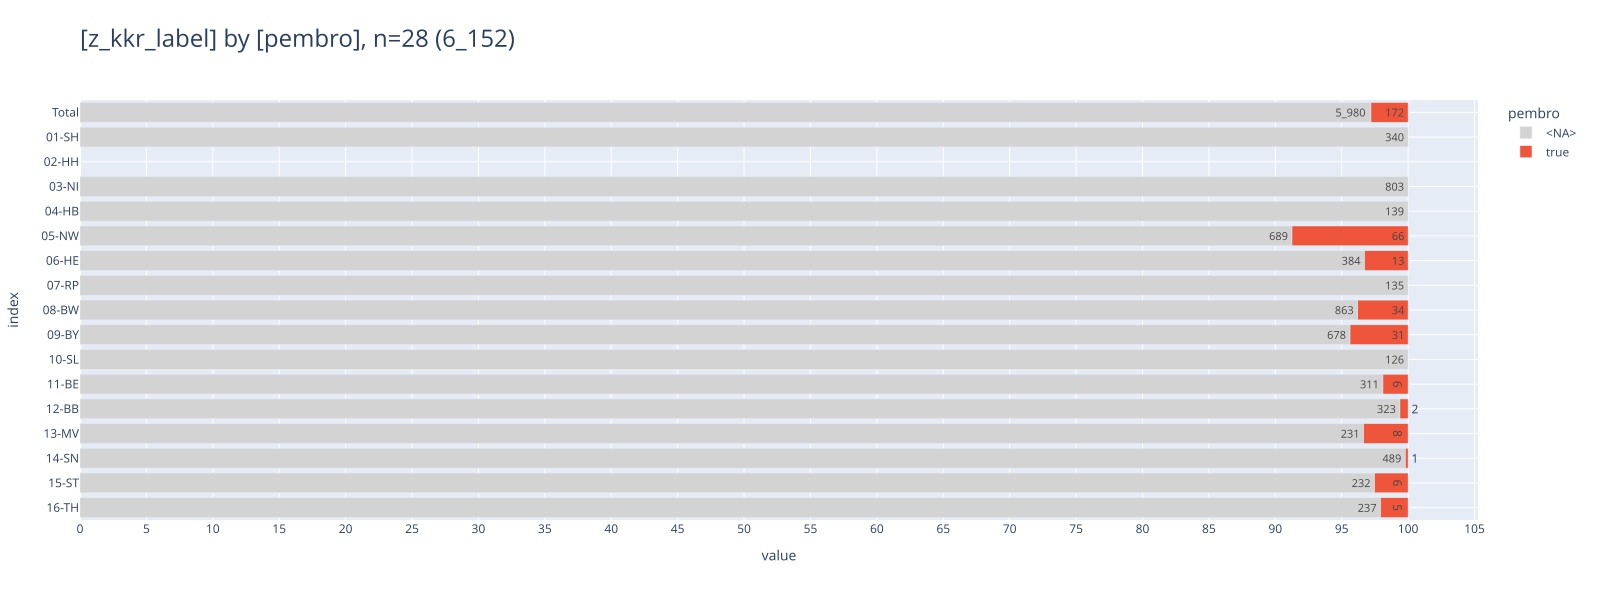

In [10]:
pls.plot_stacked_bars(
    db_2_tum.project(
        "z_kkr_label, has_pembro::text as pembro",
    ).to_df(),
    relative=True,
    orientation="h",
    show_total=True,
    kkr_col="z_kkr_label",
)

## old

In [11]:
t_ops = con.sql("""--sql
        select  z_tum_id, Code, Version
                ,(Code ilike '5-401.11%') as is_ops_5401
        from OPS
    """)

# !  Pembro can also occur in protocol name
t_subst = con.sql("""--sql
        select 
                coalesce(subst.z_tum_id, prot.z_tum_id) as z_tum_id
                ,SYST_TypSubstanzATC_Code as subst_code
                ,subst.Bezeichnung as subst_name
                ,prot.Bezeichnung as prot_name
                ,(ifnull(SYST_TypSubstanzATC_Code,'') = 'L01FF02') or
                    (regexp_matches(subst.Bezeichnung, 'Pembro|Keytruda',  'i')) or
                    (regexp_matches(prot.Bezeichnung, 'Pembro|Keytruda',  'i'))
                    as is_pembro
                --,(subst.Bezeichnung is null and (regexp_matches(prot.Bezeichnung, 'Pembro|Keytruda',  'i')) and not (ifnull(SYST_TypSubstanzATC_Code,'') = 'L01FF02')) as lol
        from Substanz subst
        full join Protokoll prot on subst.z_tum_id = prot.z_tum_id
    """)

t_tum = con.sql("""--sql
        select  t.z_tum_id
                ,z_kkr_label
                ,z_icd10
                ,z_dy
                ,Diagnosesicherung
                ,z_t_p_1, z_n_p_1, z_m_p_1
                ,UICC_Stadium_p
                ,y_Symbol_p
                ,Grading
                ,Morphologie_Code
                ,HormonrezeptorStatus_Oestrogen, Her2neuStatus, HormonrezeptorStatus_Progesteron, Praetherapeutischer_Menopausenstatus
                ,z_first_treatment, z_first_treatment_after_days, z_last_tum_status
                
        from Tumor t
        where z_icd10_3d in ('C50','D05')
        and z_sex = 'W'
        and z_dy between 2020 and 2023
    """)

tbl.descr_db(t_ops.filter("is_ops_5401"), 'is_ops_5401')
tbl.descr_db(t_subst.filter("is_pembro"), 'is_pembro')
tbl.descr_db(t_tum, 'tum')

<!-- START_TOKEN -->

🗄️ is_ops_5401	150_263, 4
	("z_tum_id, Code, Version, is_ops_5401")


<!-- END_TOKEN -->

┌──────────────────────────────────────┬──────────┬─────────┬─────────────┐
│               z_tum_id               │   Code   │ Version │ is_ops_5401 │
│               varchar                │ varchar  │ varchar │   boolean   │
├──────────────────────────────────────┼──────────┼─────────┼─────────────┤
│ f2ed656c-fb4d-4ba1-809d-b6e8d6a3a014 │ 5-401.11 │ 2020    │ true        │
│ ed66180c-28be-496c-9ca7-63df2de08546 │ 5-401.11 │ 2020    │ true        │
│ 145b0873-b980-4119-a5b1-05e043e4eac9 │ 5-401.11 │ 2021    │ true        │
└──────────────────────────────────────┴──────────┴─────────┴─────────────┘



<!-- START_TOKEN -->

...

┌──────────────────────────────────────┬────────────┬───────────────┬────────────────┬───────────┐
│               z_tum_id               │ subst_code │  subst_name   │   prot_name    │ is_pembro │
│               varchar                │  varchar   │    varchar    │    varchar     │  boolean  │
├──────────────────────────────────────┼────────────┼───────────────┼────────────────┼───────────┤
│ 8949afb1-6613-4e20-aeab-b01faddafa15 │ NULL       │ Pembrolizumab │ Gemcitabinmono │ true      │
│ a9a0f7e0-6476-4051-ad0c-248a4a1f5201 │ NULL       │ Pembrolizumab │ EC             │ true      │
│ 8259e877-d34b-49cc-b4bc-dd3bae8f181e │ NULL       │ Pembrolizumab │ EC             │ true      │
└──────────────────────────────────────┴────────────┴───────────────┴────────────────┴───────────┘



<!-- START_TOKEN -->

🗄️ tum	343_375, 19
	("z_tum_id, z_kkr_label, z_icd10, z_dy, Diagnosesicherung, z_t_p_1, z_n_p_1, z_m_p_1, UICC_Stadium_p, y_Symbol_p, Grading, Morphologie_Code, HormonrezeptorStatus_Oestrogen, Her2neuStatus, HormonrezeptorStatus_Progesteron, Praetherapeutischer_Menopausenstatus, z_first_treatment, z_first_treatment_after_days, z_last_tum_status")


<!-- END_TOKEN -->

┌──────────────────────┬─────────────┬─────────┬───┬───────────────────┬──────────────────────┬──────────────────────┐
│       z_tum_id       │ z_kkr_label │ z_icd10 │ … │ z_first_treatment │ z_first_treatment_…  │  z_last_tum_status   │
│       varchar        │   varchar   │ varchar │   │      varchar      │        int32         │       varchar        │
├──────────────────────┼─────────────┼─────────┼───┼───────────────────┼──────────────────────┼──────────────────────┤
│ 8bb6d4e3-a87b-4308…  │ 05-NW       │ C50.9   │ … │ NULL              │                 NULL │ NULL                 │
│ f6b58b9e-2bfd-4591…  │ 09-BY       │ C50.4   │ … │ sy                │                   14 │ X - fehlende Angaben │
│ 3b144fd1-052c-4624…  │ 05-NW       │ C50.4   │ … │ NULL              │                 NULL │ NULL                 │
├──────────────────────┴─────────────┴─────────┴───┴───────────────────┴──────────────────────┴──────────────────────┤
│ 3 rows                                        

In [12]:
db_all = con.sql("""--sql
    select  tum.*
            ,sy.Stellung_OP
            ,sy.Anzahl_Tage_Diagnose_SYST
            ,sy.Therapieart
            ,op.Anzahl_Tage_Diagnose_OP

            ,has_ops_5401
            ,has_pembro
    from t_tum tum
    left join (select z_tum_id, max(is_ops_5401) as has_ops_5401 from t_ops group by z_tum_id ) t_ops on tum.z_tum_id = t_ops.z_tum_id
    left join (select z_tum_id, max(is_pembro) as has_pembro from t_subst group by z_tum_id ) t_subst on tum.z_tum_id = t_subst.z_tum_id
    left join OP op on tum.z_tum_id = op.z_tum_id and z_op_order = 1
    left join SYST sy on tum.z_tum_id = sy.z_tum_id and z_syst_order = 1
    --where ifnull(Anzahl_Tage_Diagnose_SYST, 0) between 0 and 365
    """)
tbl.descr_db(db_all, "all data")

<!-- START_TOKEN -->

🗄️ all data	343_375, 25
	("z_tum_id, z_kkr_label, z_icd10, z_dy, Diagnosesicherung, z_t_p_1, z_n_p_1, z_m_p_1, UICC_Stadium_p, y_Symbol_p, Grading, Morphologie_Code, HormonrezeptorStatus_Oestrogen, Her2neuStatus, HormonrezeptorStatus_Progesteron, Praetherapeutischer_Menopausenstatus, z_first_treatment, z_first_treatment_after_days, z_last_tum_status, Stellung_OP, Anzahl_Tage_Diagnose_SYST, Therapieart, Anzahl_Tage_Diagnose_OP, has_ops_5401, has_pembro")


<!-- END_TOKEN -->

┌──────────────────────┬─────────────┬─────────┬───┬─────────────┬──────────────────────┬──────────────┬────────────┐
│       z_tum_id       │ z_kkr_label │ z_icd10 │ … │ Therapieart │ Anzahl_Tage_Diagno…  │ has_ops_5401 │ has_pembro │
│       varchar        │   varchar   │ varchar │   │   varchar   │        int32         │   boolean    │  boolean   │
├──────────────────────┼─────────────┼─────────┼───┼─────────────┼──────────────────────┼──────────────┼────────────┤
│ 830c6431-af17-42e7…  │ 05-NW       │ C50.5   │ … │ HO          │                   28 │ true         │ NULL       │
│ 8b07902d-03ed-403c…  │ 05-NW       │ C50.4   │ … │ SO          │                   28 │ true         │ NULL       │
│ 605779ad-6856-4fb6…  │ 08-BW       │ C50.4   │ … │ HO          │                   24 │ true         │ NULL       │
├──────────────────────┴─────────────┴─────────┴───┴─────────────┴──────────────────────┴──────────────┴────────────┤
│ 3 rows                                                

In [13]:
# # 342_941
# n1 = con.sql("""select count(*) from t_tum""").fetchone()[0]
# n2 = db_all.aggregate("count(distinct z_tum_id) as cnt_tum").fetchone()[0]
# assert n1 == n2, "❌ wrong tum count"
# print(f"✅ tum count ok ({n1:_})")

🔵 *** df: all ***  
🟣 shape: (343_375, 24)
🟣 duplicates: 33_548  
🟠 column stats all (dtype | uniques | missings) [values]  
- index [0, 1, 2, 3, 4,]  
- z_kkr_label (object | 16 | 0 (0%)) ['01-SH', '02-HH', '03-NI', '04-HB', '05-NW',]  
- z_icd10 (object | 13 | 0 (0%)) ['C50.0', 'C50.1', 'C50.2', 'C50.3', 'C50.4',]  
- z_dy (int16 | 4 | 0 (0%)) [2020, 2021, 2022, 2023,]  
- Diagnosesicherung (object | 8 | 0 (0%)) ['0', '1', '2', '4', '5',]  
- z_t_p_1 (object | 9 | 101_810 (30%)) ['0', '1', '2', '3', '4',]  
- z_n_p_1 (object | 6 | 112_758 (33%)) ['0', '1', '2', '3', '<NA>',]  
- z_m_p_1 (object | 3 | 169_824 (49%)) ['0', '1', '<NA>',]  
- UICC_Stadium_p (object | 21 | 213_778 (62%)) ['0', '0is', '<NA>', 'I', 'IA',]  
- y_Symbol_p (object | 2 | 304_527 (89%)) ['<NA>', 'y',]  
- Grading (object | 13 | 5_392 (2%)) ['0', '1', '2', '3', '4',]  
- Morphologie_Code (object | 195 | 5_393 (2%)) ['8000/0', '8000/1', '8000/3', '8000/6', '8000/9',]  
- HormonrezeptorStatus_Oestrogen (object | 4 

,z_kkr_label,z_icd10,z_dy,Diagnosesicherung,z_t_p_1,z_n_p_1,z_m_p_1,UICC_Stadium_p,y_Symbol_p,Grading,...,Praetherapeutischer_Menopausenstatus,z_first_treatment,z_first_treatment_after_days,z_last_tum_status,Stellung_OP,Anzahl_Tage_Diagnose_SYST,Therapieart,Anzahl_Tage_Diagnose_OP,has_ops_5401,has_pembro
0,09-BY,C50.8,2020,7,0,0,0,<NA>,y,2,...,3,op,0,V - Vollremission (complete),N,48,CH,0,False,False
1,13-MV,C50.2,2022,7,1,0,0,IA,<NA>,2,...,3,sy,22,K - keine Änderung,A,22,HO,34,True,False
2,05-NW,C50.8,2020,7,<NA>,<NA>,<NA>,<NA>,<NA>,2,...,1,sy,10,P - Progression,N,10,HO,38,True,<NA>


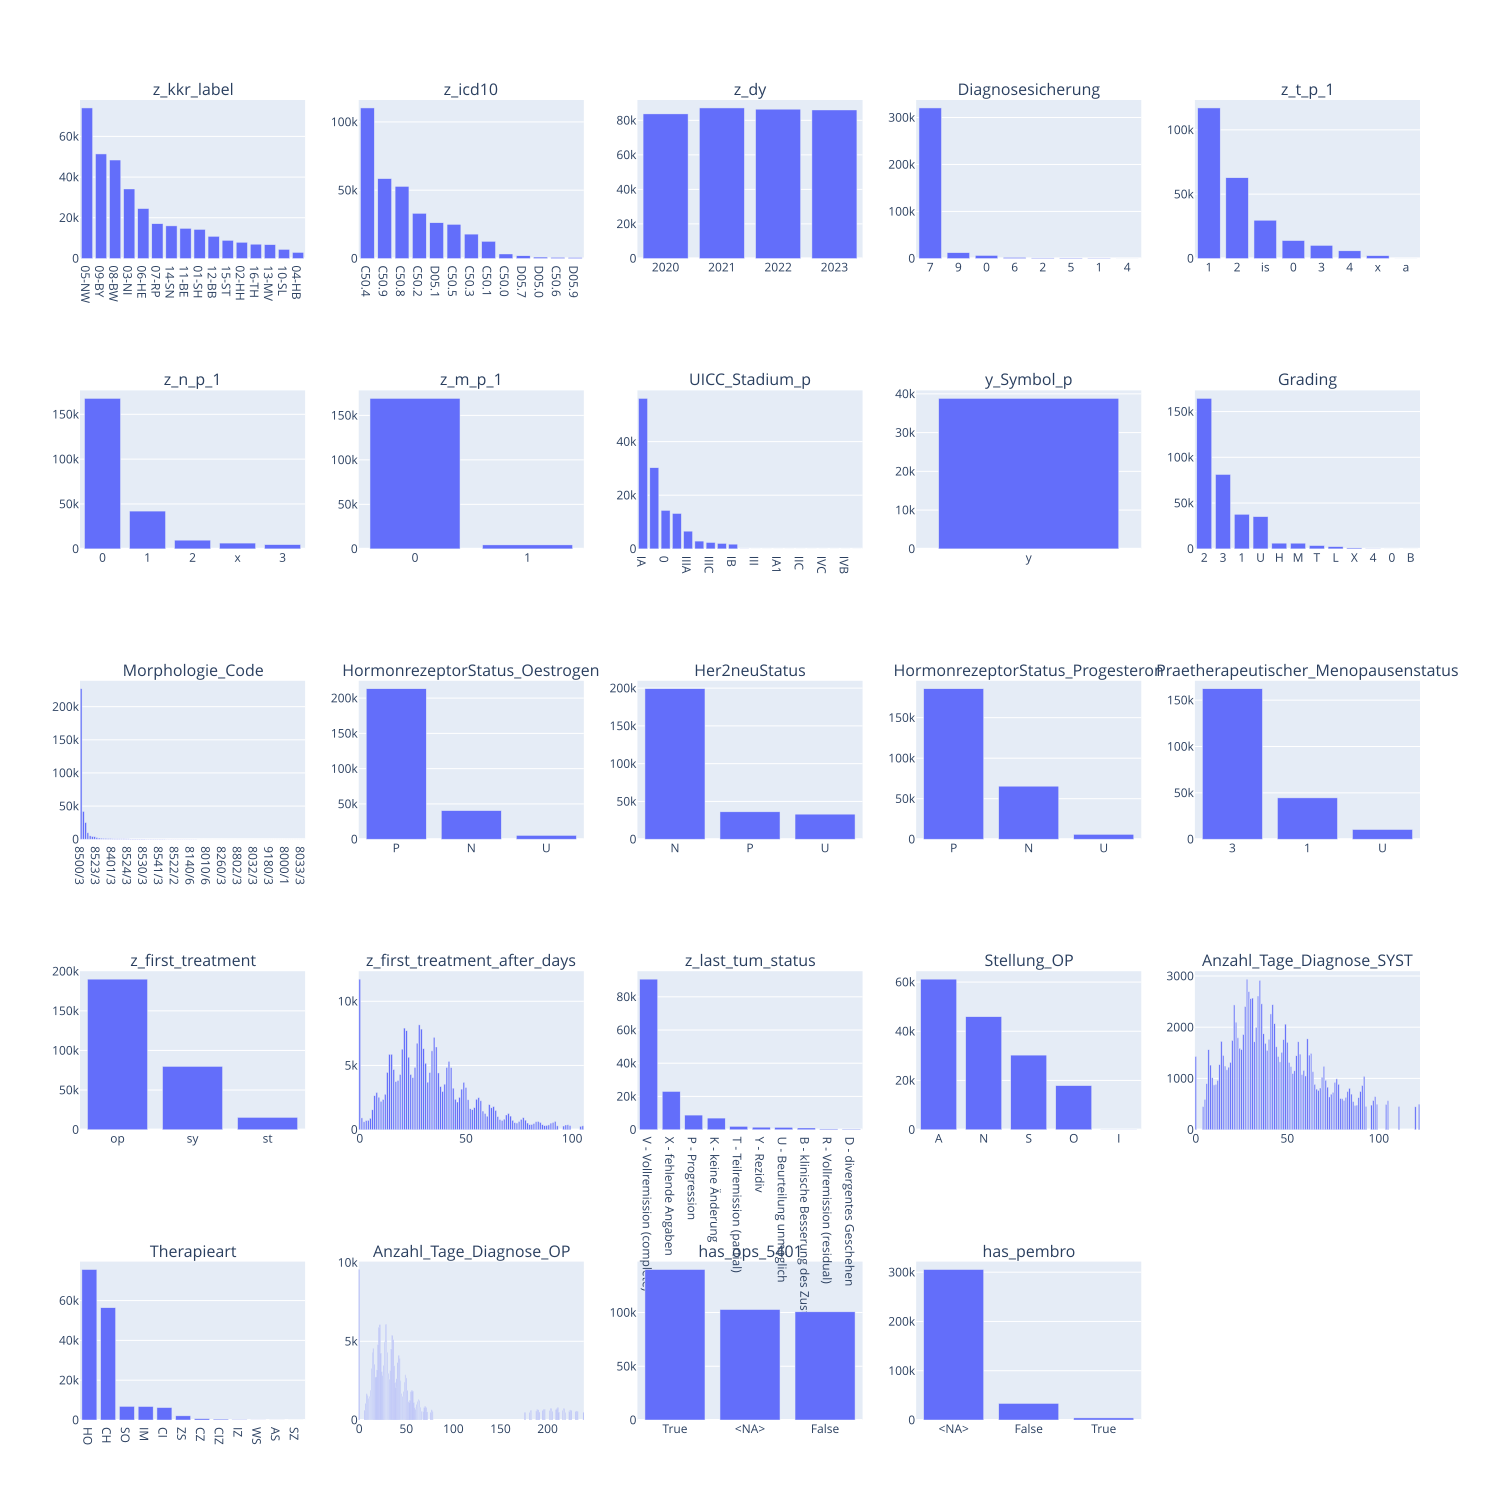

In [14]:
tbl.describe_df(db_all.project("* exclude(z_tum_id)").to_df(), 'all', use_plot=True, fig_cols=5)

## <a id='toc1_3_'></a>[🕹️ interactive](#toc0_)

In [15]:
if False:
    import pygwalker as pyg

    spec="config/pygwalker_spec_N3C50.json"
    hlp.add_measures_to_pyg_config(spec, nodes=[
                                ("cnt_tum", "count(distinct z_tum_id)"), 
                                # ("cnt_syst", "count(distinct SYSTId)")
                                ])

    _=pyg.walk(db_raw.to_df(), kernel_computation=True, spec=spec)

## <a id='toc1_4_'></a>[📉 plots](#toc0_)

### <a id='toc1_4_1_'></a>[HormonrezeptorStatus_Oestrogen](#toc0_)

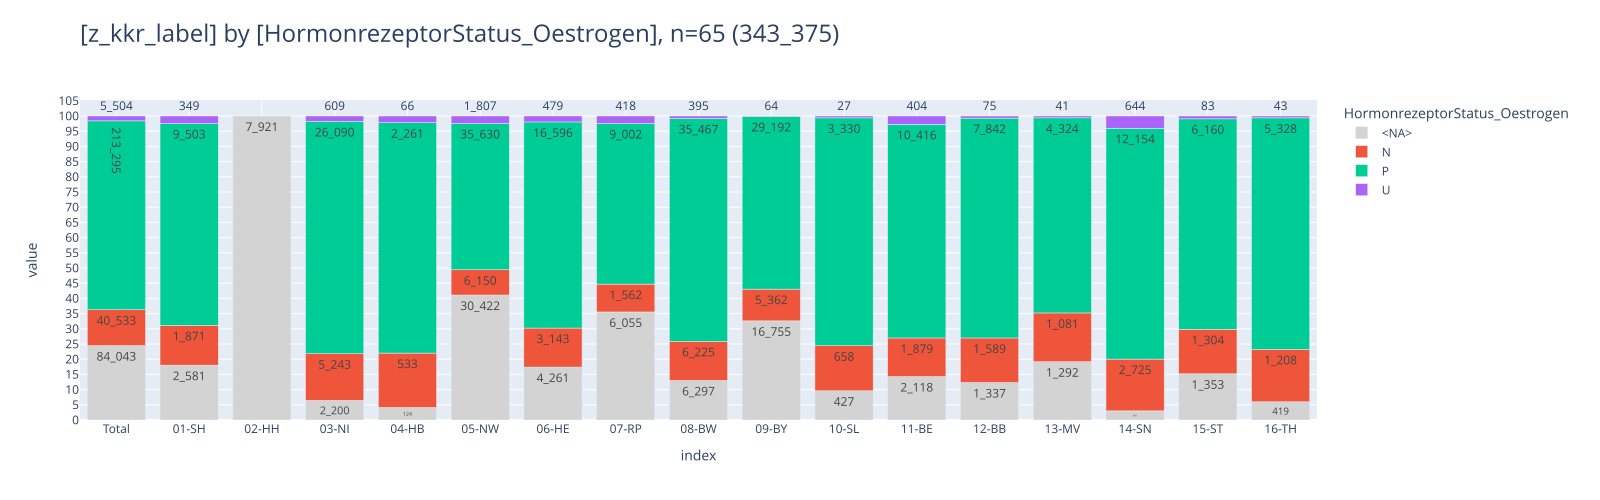

In [16]:
_df = db_all.project("z_kkr_label, HormonrezeptorStatus_Oestrogen").to_df()
_=pls.plot_stacked_bars(_df, relative=True, height=500, show_total=True,)

### <a id='toc1_4_2_'></a>[Anzahl_Tage_Diagnose_SYST](#toc0_)

#### <a id='toc1_4_2_1_'></a>[groups](#toc0_)

In [17]:
t_syst = con.sql("select * from SYST")

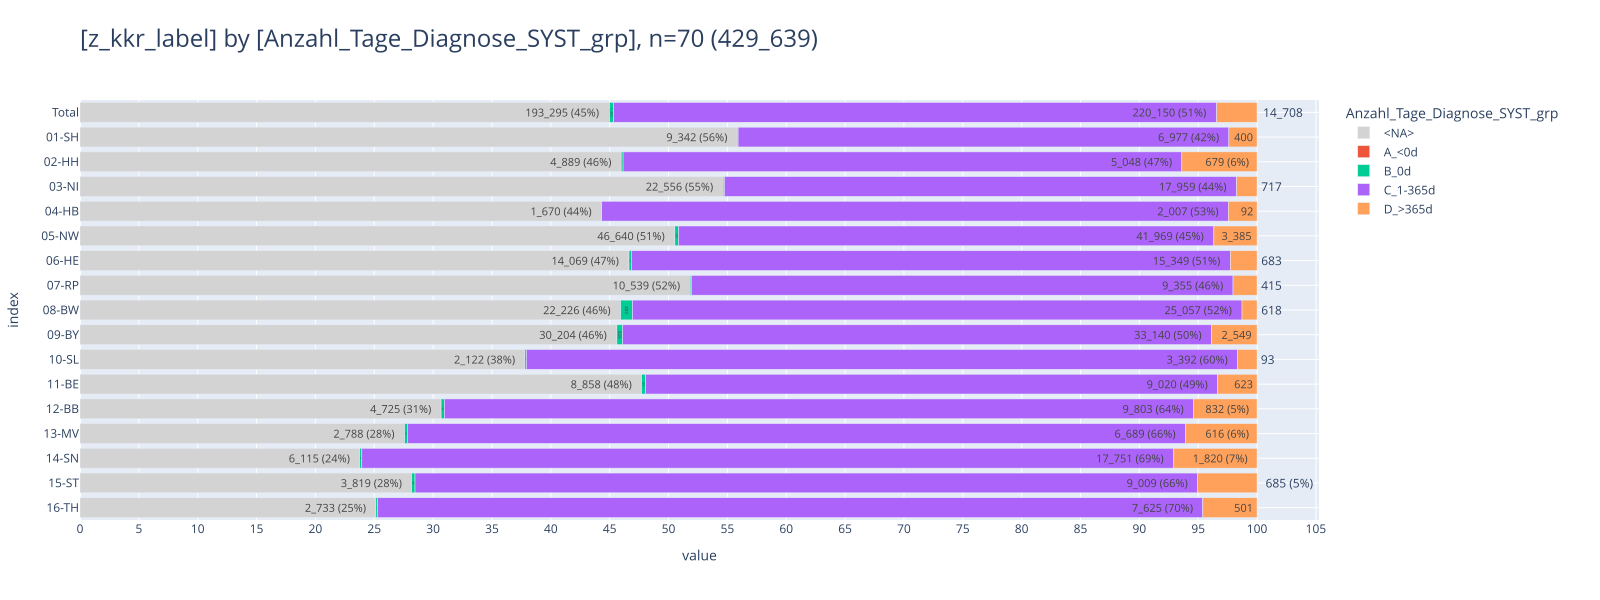

In [18]:
# # ! important: only join SYST x TUM, no OP
_df = (t_syst
    # * join all (filtered) tums
    .join(t_tum, "z_tum_id", "right")
    .project("""--sql
        z_kkr_label,
        case 
            when Anzahl_Tage_Diagnose_SYST is null then '<NA>'
            when Anzahl_Tage_Diagnose_SYST < 0 then 'A_<0d'
            when Anzahl_Tage_Diagnose_SYST = 0 then 'B_0d'
            when Anzahl_Tage_Diagnose_SYST < 365 then 'C_1-365d'
            else 'D_>365d' end as Anzahl_Tage_Diagnose_SYST_grp
        """)
    .to_df()
)
_=pls.plot_stacked_bars(_df, relative=True, height=600, show_total=True, orientation='h', show_pct_bar=True,)

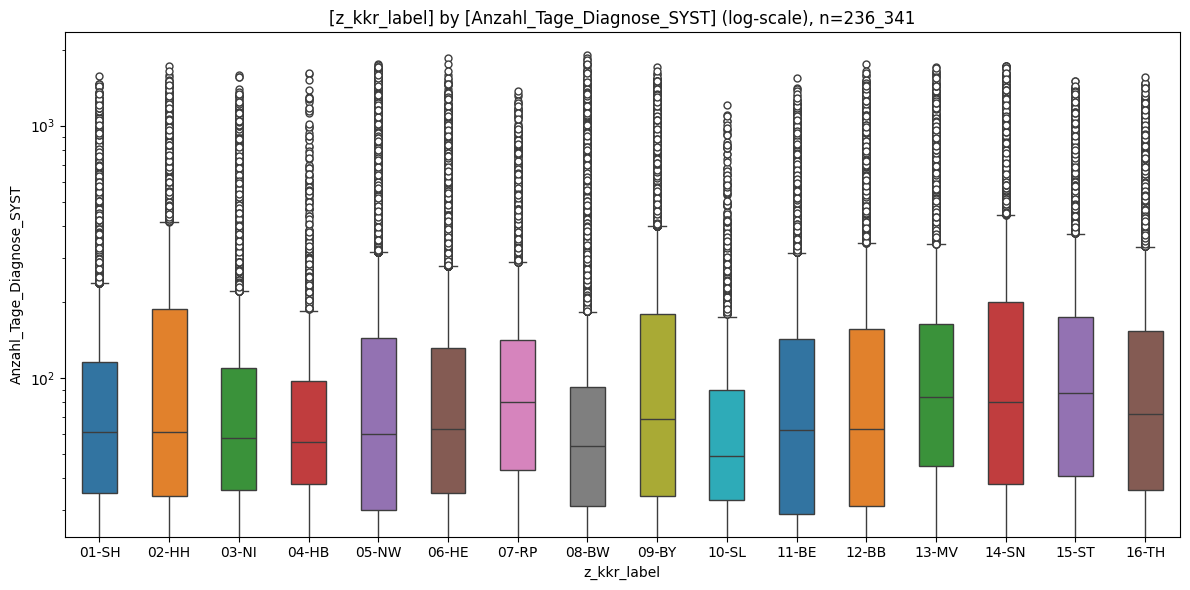


column (n = 236_341)      |    present     | min | lower |  q25  | median |  mean  |  q75   | upper |  max  |  std   |  cv 
--------------------------+----------------+-----+-------+-------+--------+--------+--------+-------+-------+--------+-----
Anzahl_Tage_Diagnose_SYST | 236_341 (100%) |   0 |     0 | 34.00 |  64.00 | 125.85 | 137.00 |   291 | 1_901 | 179.19 | 1.42


item (n = 236_341) | count  | min  | lower |  q25  | median |  mean  |  q75   | upper  |   max    |  std   |  cv 
-------------------+--------+------+-------+-------+--------+--------+--------+--------+----------+--------+-----
01-SH              |  7_390 | 0.00 |  0.00 | 35.00 |  61.00 | 114.38 | 116.00 | 237.00 | 1_578.00 | 165.32 | 1.45
02-HH              |  5_744 | 0.00 |  0.00 | 34.00 |  61.00 | 163.81 | 187.00 | 414.00 | 1_728.00 | 245.32 | 1.50
03-NI              | 18_714 | 0.00 |  0.00 | 36.00 |  58.00 | 102.82 | 110.00 | 221.00 | 1_581.00 | 134.56 | 1.31
04-HB              |  2_100 | 0.00 |  0.00 | 38.00 |  5

In [19]:
_df =(t_syst
    # * join all (filtered) tums
    .join(t_tum, "z_tum_id", "right")
    # * neg values impact median calc
    .filter("Anzahl_Tage_Diagnose_SYST >= 0")
    .project("z_kkr_label, Anzahl_Tage_Diagnose_SYST")
    .to_df()
)
pls.plot_boxes_large(_df, use_log=True,)